In [1]:
from glob import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cpi
#cpi.update()

In [2]:
prediction_files = glob("./random_sample/*.csv")
year_num_inflation_map = {file[-8:-4]: 0 for file in prediction_files}

for file in prediction_files:
    df = pd.read_csv(file)
    year = file[-8:-4]
    year_num_inflation_map[year] = len(df[(df["triples"]!="[]")])/len(df)

print(year_num_inflation_map)

{'1987': 0.003286878779910597, '2005': 0.03310231625022798, '2019': 0.015129420342690485, '1985': 0.0001325556733828208, '1990': 0.01660872923908845, '1984': 0.00013157894736842105, '2008': 0.04050241194138527, '2016': 0.015808122104115564, '2002': 0.0136986301369863, '2015': 0.018680517587023875, '2020': 0.00790047221213222, '1988': 0.008369868473495417, '2013': 0.01829601310759148, '1994': 0.027589227063717976, '1992': 0.016191210485736313, '2000': 0.02557568034950396, '2009': 0.01694143364605155, '2010': 0.01972062448644207, '2004': 0.03277494537509104, '1989': 0.0157908361377168, '1996': 0.03698642616379703, '1999': 0.027378445197326254, '1997': 0.038885347418267914, '2017': 0.023527266095203357, '2018': 0.019146608315098467, '2006': 0.03595874783243588, '2022': 0.03474058539254126, '1986': 0.0, '2003': 0.015430971512052593, '2012': 0.024752024752024752, '1998': 0.02584167424931756, '1995': 0.03753424657534247, '2021': 0.019210750449512634, '2023': 0.05345911949685535, '2014': 0.02

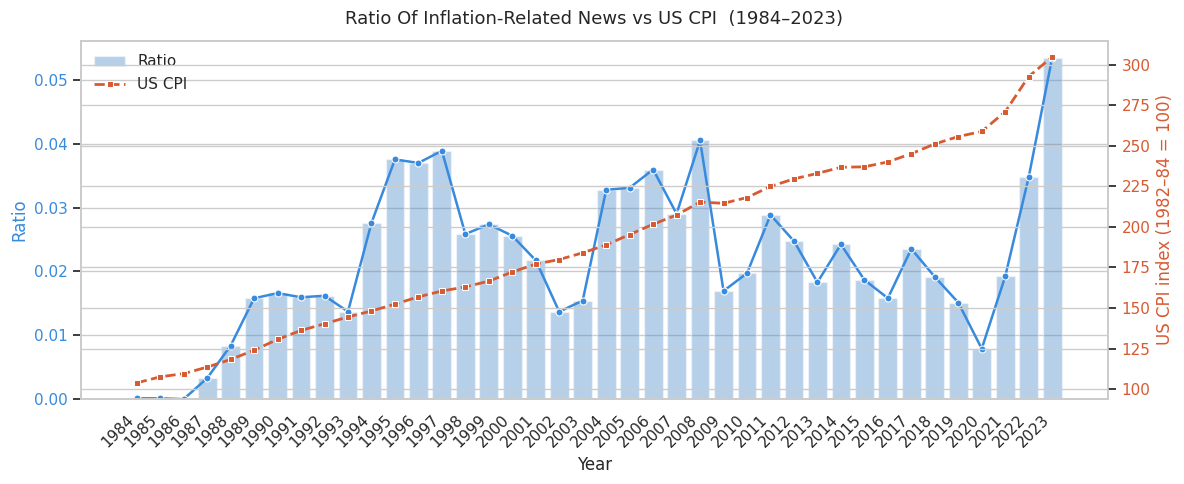

In [3]:
def plot_inflation_map(year_num_inflation_map: dict, figsize=(12, 5)):
    """
    Visualize a growing year→count dict against the US CPI index.

    Parameters
    ----------
    year_num_inflation_map : dict
        Keys are year strings or ints, values are numeric counts.
        Safe to call repeatedly as the dict grows.
    figsize : tuple
        Figure size passed to matplotlib.
    """
    # normalise keys to int, sort chronologically
    data = {int(k): v for k, v in year_num_inflation_map.items()}
    years = sorted(data.keys())
    counts = [data[y] for y in years]

    # fetch CPI live for each year present in the dict
    cpi_vals = []
    for y in years:
        try:
            cpi_vals.append(cpi.get(y))
        except Exception:
            cpi_vals.append(None)

    has_cpi = any(v is not None for v in cpi_vals)

    # layout: two y-axes
    sns.set_theme(style="whitegrid", palette="muted")
    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx() if has_cpi else None

    # bars + line for model counts
    x = range(len(years))
    sns.barplot(x=list(x), y=counts, ax=ax1,
                color="#378ADD", alpha=0.4, label="Ratio")
    sns.lineplot(x=list(x), y=counts, ax=ax1,
                 color="#378ADD", linewidth=1.8,
                 marker="o", markersize=5, label="_nolegend_")

    ax1.set_ylabel("Ratio", color="#378ADD")
    ax1.tick_params(axis="y", labelcolor="#378ADD")
    ax1.set_xlabel("Year")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels([str(y) for y in years], rotation=45, ha="right")

    # dashed CPI line on second axis
    if has_cpi and ax2 is not None:
        cpi_x = [i for i, v in enumerate(cpi_vals) if v is not None]
        cpi_y = [v for v in cpi_vals if v is not None]
        sns.lineplot(x=cpi_x, y=cpi_y, ax=ax2,
                     color="#D85A30", linewidth=2,
                     linestyle="--", marker="s", markersize=4,
                     label="US CPI")
        ax2.set_ylabel("US CPI index (1982–84 = 100)", color="#D85A30")
        ax2.tick_params(axis="y", labelcolor="#D85A30")
        if ax2.get_legend():
            ax2.get_legend().remove()

    # merged legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = (ax2.get_legend_handles_labels() if ax2 else ([], []))
    ax1.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False)

    plt.title(f"Ratio Of Inflation-Related News vs US CPI  ({min(years)}–{max(years)})",
              fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()


# usage
plot_inflation_map(year_num_inflation_map)